In [83]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt

In [84]:
def get_results(base, mod, v):
    preds = []
    for vid in test_vids:
        #print(base.format(mod, v, vid))
        p = np.load(base.format(mod, v, vid))
        p = p.argmax(axis=1)
        preds += list(p)
    preds = np.array(preds)
    return preds

def get_f1_dict(suffix='states'):
    mod_base = '/home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/{}-5-good_sample-0_markers/version_{}/{}_' + suffix + '.npy'
    f1_meta = {}
    mods = ['nope', 'all', 'rotate', 'shift', 'gauss', 'shot']

    for mod in mods:
        f1_meta[mod] = []
        for v in range(5):
            preds = get_results(mod_base, mod,v)
            f1 = f1_score(states[states>0], preds[states>0], average=None)
            f1_meta[mod].append([np.mean(f1)] + list(f1))
            
    # aggregate results
    f1_plot = {}
    for mod in mods:
        mean_list = []
        sd_list = []
        for p in range(len(labels)):
            mean = np.mean([a[p] for a in f1_meta[mod]])
            sd = np.std([a[p] for a in f1_meta[mod]])/5
            mean_list.append(mean)
            sd_list.append(sd)
        f1_plot[mod] = (mean_list, sd_list)
        
    return f1_plot

    
def plot_f1(f1_plot, it='regular markers'):
    # Numbers of pairs of bars you want
    N = len(label_names)
    # Position of bars on x-axis
    ind = np.arange(N)

    colors = ['black', 'grey', 'lightgrey', 'slategrey', 'peru', 'brown']
    # Figure size
    plt.figure(figsize=(8,5))

    # Width of a bar 
    width = 0.15     
    i=0
    for mod, (mean, sd) in f1_plot.items():
        if i==0:
            print(mean)
        # Plotting
        label = mod
        if mod == 'nope':
            label='none'
        plt.bar(ind + width*i, mean, width, label=label, color=colors[i],yerr=sd)
        plt.xlabel('classes')
        plt.ylabel('F1 score')
        plt.title('F1 scores with different transforms ({})'.format(it))

        # xticks()
        # First argument - A list of positions at which ticks should be placed
        # Second argument -  A list of labels to place at the given locations
        plt.xticks(ind + width, label_names)
        i+=1

    # Finding the best position for legends and putting it
    plt.legend(loc='best')
    plt.show()

In [85]:
test_vids = [
    'churchlandlab_CSHL045_2020-02-27-001',
    'cortexlab_KS020_2020-02-06-001',
    'hoferlab_SWC_043_2020-09-15-001',
    'mrsicflogellab_SWC_052_2020-10-22-001',
    'wittenlab_ibl_witten_27_2021-01-21-001',
]
label_names = ['avg', 'still', 'move', 'wheel_turn', 'groom']

In [86]:
# load gt labels
base = '/home/bsb2144/daart_utils/data/ibl/labels-hand/{}_labels.csv'
labels = {}
states = []
for vid in test_vids:
    labs = pd.read_csv(base.format(vid),index_col=0).to_numpy()
    labs = labs.argmax(axis=1)
    states += list(labs)
    labels[vid] = labs
states = np.array(states)

In [87]:
# graph accuracy
suffix='states'
mod_base = '/home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/{}-5-good_sample-0_markers/version_{}/{}_' + suffix + '.npy'
mods = ['nope', 'all', 'rotate', 'shift', 'gauss', 'shot']
gt = states[states>0]
for mod in mods:
    print(mod)
    for v in range(5):
        p=get_results(mod_base, mod, v)[states>0]
        acc = accuracy_score(gt,p)
        print(acc)

nope
0.9227816329543777
0.9102318027461982
0.9263251144249225
0.9096412225011073
0.9128894138491067
all
0.91525173482947
0.9029971947438358
0.9161376051971062
0.9153993798907426
0.9151040897681972
rotate
0.925586889118559
0.9199763767901964
0.9223386977705595
0.9103794478074708
0.9239627934445592
shift
0.9149564447069245
0.9183522811161967
0.9252915989960135
0.9223386977705595
0.9155470249520153
gauss
0.9223386977705595
0.9080171268271077
0.9249963088734682
0.920124021851469
0.918204636054924
shot
0.9202716669127418
0.9040307101727447
0.9187952163000148
0.9133323490329248
0.9056548058467444


In [76]:
f1_plot = get_f1_dict()

[0.9134246889113387, 0.9447554852314379, 0.8197226156926398, 0.893219764515702, 0.9960008902055753]


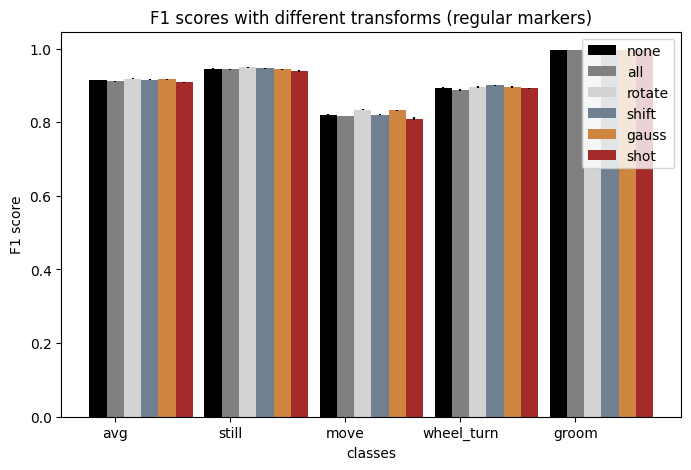

In [77]:
plot_f1(f1_plot)

[0.9072175174681929, 0.9511768450581762, 0.7991522442944576, 0.8926239676021371, 0.985917012918]


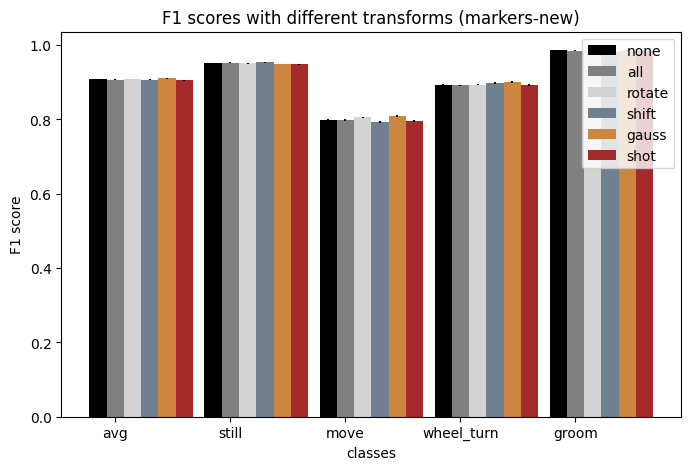

In [78]:
it = 'markers-new'
f1_plot_new = get_f1_dict(it)
plot_f1(f1_plot_new, it)

[0.9035633496533894, 0.9470296932665463, 0.7907469683631463, 0.8900248780374543, 0.9864518589464109]


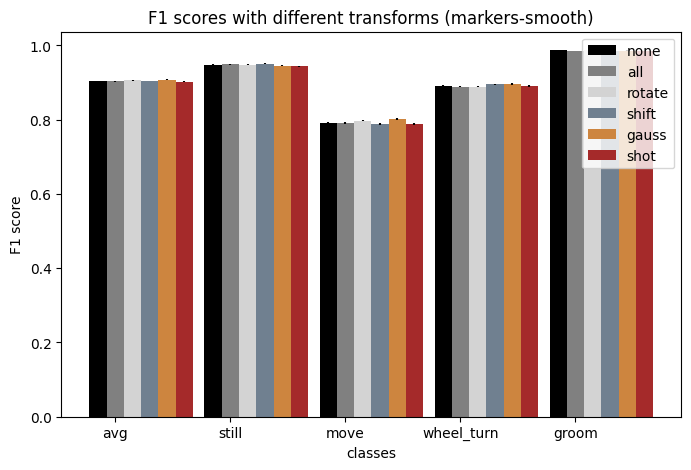

In [79]:
it = 'markers-smooth'
f1_plot_smooth = get_f1_dict(it)
plot_f1(f1_plot_smooth, it)

# Save predicitons on markers-new and markers-smooth data

In [72]:
# inf on other session types

test_vids = [
    'churchlandlab_CSHL045_2020-02-27-001',
    'cortexlab_KS020_2020-02-06-001',
    'hoferlab_SWC_043_2020-09-15-001',
    'mrsicflogellab_SWC_052_2020-10-22-001',
    'wittenlab_ibl_witten_27_2021-01-21-001',
]
# vid_map = {
#     '46794e05-3f6a-4d35-afb3-9165091a5a74': 'churchlandlab_CSHL045_2020-02-27-001',
#     'c7b0e1a3-4d4d-4a76-9339-e73d0ed5425b': 'cortexlab_KS020_2020-02-06-001',
#     #'db4df448-e449-4a6f-a0e7-288711e7a75a': ‘danlab_DY_009_2020-02-27-001’,
#     #'54238fd6-d2d0-4408-b1a9-d19d24fd29ce': ‘danlab_DY_018_2020-10-15-001’,
#     'f3ce3197-d534-4618-bf81-b687555d1883': 'hoferlab_SWC_043_2020-09-15-001',
#     #'493170a6-fd94-4ee4-884f-cc018c17eeb9': ‘hoferlab_SWC_061_2020-11-23-001’,
#     '7cb81727-2097-4b52-b480-c89867b5b34c': 'mrsicflogellab_SWC_052_2020-10-22-001',
#     #'1735d2be-b388-411a-896a-60b01eaa1cfe': ‘mrsicflogellab_SWC_058_2020-12-11-001’,
#     #'ff96bfe1-d925-4553-94b5-bf8297adf259': ‘wittenlab_ibl_witten_26_2021-01-27-002’,
#     '73918ae1-e4fd-4c18-b132-00cb555b1ad2': 'wittenlab_ibl_witten_27_2021-01-21-001'
# }



In [10]:
vid_map = {
    'churchlandlab_CSHL045_2020-02-27-001': '46794e05-3f6a-4d35-afb3-9165091a5a74',
    'cortexlab_KS020_2020-02-06-001': 'c7b0e1a3-4d4d-4a76-9339-e73d0ed5425b',
    'hoferlab_SWC_043_2020-09-15-001': 'f3ce3197-d534-4618-bf81-b687555d1883',
    'mrsicflogellab_SWC_052_2020-10-22-001': '7cb81727-2097-4b52-b480-c89867b5b34c',
    'wittenlab_ibl_witten_27_2021-01-21-001': '73918ae1-e4fd-4c18-b132-00cb555b1ad2'
}

def get_marker_file(vid, input_type):
    file_name = vid_map[vid]
    file_path = vid_path.format(input_type, file_name)
    return file_path


In [17]:
# reg model
import os
import yaml
import torch
from daart.models import Segmenter
from daart.data import DataGenerator, compute_sequence_pad
from daart.eval import get_precision_recall, run_lengths
from daart.io import get_expt_dir, find_experiment
from daart.transforms import ZScore
from daart_utils.data import DataHandler
from daart_utils.models import compute_model_predictions, get_default_hparams


data_path = '/home/bsb2144/daart_utils/data/ibl'
mod_path = '/home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/{}-5-good_sample-0_markers/version_{}/'
vid_path = '/home/bsb2144/daart_utils/data/ibl/{}/{}_labeled.csv'
mods = ['nope', 'all', 'rotate', 'shift', 'gauss', 'shot']

save_path = '/home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/{}-5-good_sample-0_markers/version_{}/{}_{}.npy'
input_type = 'markers-smooth'
#f-new

for mod in mods:
    for v in range(5):
        model_dir = mod_path.format(mod,v)
        # load model
        model_file = os.path.join(model_dir, 'last_model.pt')
        arch_file = os.path.join(model_dir, 'hparams.yaml')

        print('Loading model defined in %s' % arch_file)
        with open(arch_file, 'rb') as f:
            hparams_new = yaml.safe_load(f)
        model_0 = Segmenter(hparams_new)
        model_0.load_state_dict(torch.load(model_file, map_location=lambda storage, loc: storage))
        model_0.to(hparams_new['device'])
        model_0.eval()
        
        # inf and save res
        for expt_id in test_vids:
            markers_file = vid_path.format(input_type, expt_id)
            hand_labels_file = os.path.join(data_path, 'labels-hand', expt_id + '_labels.csv')
            # define data generator signals
            signals = ['markers']
            transforms = [ZScore()]
            paths = [markers_file]
            print(markers_file)
            # build data generator
            data_gen_test = DataGenerator(
                [expt_id], [signals], [transforms], [paths], device=hparams_new['device'], 
                batch_size=hparams_new['batch_size'], trial_splits='9;1;0;0', #'1;1;0;0', 
                sequence_pad=hparams_new['sequence_pad'], sequence_length=hparams_new['sequence_length'],
                input_type=input_type)
            print(data_gen_test)
            tmp = model_0.predict_labels(data_gen_test, return_scores=True)
            labels_pred = np.vstack(tmp['labels'][0])[:100000]
            
            # save preds
            save_to = save_path.format(mod, v, expt_id, input_type)
            np.save(save_to, labels_pred)

Loading model defined in /home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/nope-5-good_sample-0_markers/version_0/hparams.yaml
/home/bsb2144/daart_utils/data/ibl/markers-smooth/churchlandlab_CSHL045_2020-02-27-001_labeled.csv
loadinf features from /home/bsb2144/daart_utils/data/ibl/markers-smooth/churchlandlab_CSHL045_2020-02-27-001_labeled.csv
vals (319703, 3)
Generator contains 1 SingleDataset objects:
churchlandlab_CSHL045_2020-02-27-001
    signals: ['markers']
    transforms: OrderedDict([('markers', ZScore())])
    paths: OrderedDict([('markers', '/home/bsb2144/daart_utils/data/ibl/markers-smooth/churchlandlab_CSHL045_2020-02-27-001_labeled.csv')])

/home/bsb2144/daart_utils/data/ibl/markers-smooth/cortexlab_KS020_2020-02-06-001_labeled.csv
loadinf features from /home/bsb2144/daart_utils/data/ibl/markers-smooth/cortexlab_KS020_2020-02-06-001_labeled.csv
vals (243992, 3)
Generator contains 1 SingleDataset objects:
cortexlab_KS020_2020-02-06-001
    signals: ['markers']
    transf

In [18]:
print('done')

done


In [80]:
# # reformat pv to pos for f new ans f smooth

# mod_path = '/home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/{}-5-good_sample-0_markers/version_{}/'
# vid_path = '/home/bsb2144/daart_utils/data/ibl/{}/{}_features_smooth.csv'

# #save_path = '/home/bsb2144/daart_utils/data/ibl/markers-smooth/{}_markers-smooth.csv'
# save_path = '/home/bsb2144/daart_utils/data/ibl/markers-smooth/{}_labeled.csv'

# input_type = 'features_smooth'
# for vid in test_vids:
#     df = pd.read_csv(vid_path.format(input_type, vid_map[vid]), index_col=0)
#     print(df.shape)
#     df = df.drop(['paw_x_vel', 'paw_y_vel', 'wheel_acc'], axis=1)
#     display(df.head())
#     print(df.shape)
#     #df.to_csv(save_path.format(vid))